# Stability exploration: output.csv
Using `exp_parameters` as the group identifier.<br>
We use the experiments 'Cable default' for stable responsiveness<br>
and 'VDSL mad' with mad=5 for stable throughput analysis

In [20]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import operator as op
warnings.filterwarnings('ignore')

df = pd.read_csv('output_31-05-2026_15-54-03.csv')
df2 = pd.read_csv('output_stability.csv')

df = pd.concat([df, df2], ignore_index=True)

pd.options.mode.use_inf_as_na = True

df = df.dropna(subset=['dl_rpm_p','dl_rpm_trimmed', 'ul_rpm_p', 'ul_rpm_trimmed'])

responsiveness_df = df[df['exp_parameters'] == 'Cable']
throughput_df = df[df['exp_parameters'] == 'VDSL mad']

throughput_df = throughput_df[throughput_df['mad'] == 5]

print(responsiveness_df['exp_parameters'].unique())
print(throughput_df['exp_parameters'].unique())


['Cable']
['VDSL mad']


In [21]:
rpm_cols = [c for c in df.columns if 'rpm' in c.lower()]

fieldnames = ['exp_parameters']
environment_parameters = ['dl_capacity', 'ul_capacity', 'dl_delay', 'ul_delay']

rpm_parameters = ['id', 'inc', 'inp', 'mad', 'mnp', 'mps', 'p', 'ptc', 'sdt', 'timeout', 'tmp']

dl_test_output = ['dl_stable_throughput', 'dl_stable_responsiveness', 'dl_throughput', 'dl_connections',
                   'dl_max_path_mtu', 'dl_max_send_mss', 'dl_max_recv_mss', 'dl_retransmissions',
                   'dl_reorder', 'dl_avg_rtt', 'dl_rpm_p', 'dl_rpm_trimmed']

ul_test_output = ['ul_stable_throughput', 'ul_stable_responsiveness', 'ul_throughput', 'ul_connections',
                   'ul_max_path_mtu', 'ul_max_send_mss', 'ul_max_recv_mss', 'ul_retransmissions',
                   'ul_reorder', 'ul_avg_rtt', 'ul_rpm_p', 'ul_rpm_trimmed']

final_test_output = ['final_rpm_p', 'final_rpm_trimmed']

relative_test_output = ['ub_base_rpm_p', 'ub_base_rpm_trimmed', 'base_rpm_p', 'base_rpm_trimmed',
                         'wc_effect_p', 'wc_effect_trimmed']

outputs = dl_test_output + ul_test_output + final_test_output + relative_test_output

not_relevant = ["mtu", "mss"]

outputs_for_plots = [
    item for item in outputs 
    if not any(sub in item for sub in not_relevant)
]


bool_cols = ['dl_stable_throughput', 'dl_stable_responsiveness',
             'ul_stable_throughput', 'ul_stable_responsiveness']

relevant_parameters = ['connectionsPerInterval', 'connectionsInitial', 'movingAverageDistance', 'maxParallelConnections', 
                       'probesPerSecond', 'percentageOfResults', 'capacityOfProbes', 'stabilityCutoff', 'calculationTime']
for c in bool_cols:
    if c in df.columns and df[c].dtype == object:
        df[c] = df[c].map({'True': True, 'False': False})

environments = ['VDSL', 'Cable', 'Fiber']

# rename the parameters to something readable:
rename_map = {
    'id': 'intervalDuration',
    'inc': 'connectionsPerInterval', 
    'inp': 'connectionsInitial', 
    'mad': 'movingAverageDistance', 
    'mnp': 'maxParallelConnections', 
    'mps': 'probesPerSecond', 
    'p': 'percentageOfResults', 
    'ptc': 'capacityOfProbes', 
    'sdt': 'stabilityCutoff', 
    'timeout': 'calculationTime',
    'tmp': 'trimPercentage'
}

default_values = {
    'connectionsPerInterval': 1,
    'connectionsInitial': 1,
    'movingAverageDistance': 4,
    'maxParallelConnections': 16,
    'probesPerSecond': 100,
    'percentageOfResults': 90,
    'capacityOfProbes': 0.05,
    'stabilityCutoff': 5,
    'calculationTime': 20
}

## Stability Responsiveness

In [22]:
# 1. Drop random True rows to make it even
boolean_counts = responsiveness_df['dl_stable_responsiveness'].value_counts()

diff = boolean_counts[True] - boolean_counts[False]

true_indices = responsiveness_df[responsiveness_df['dl_stable_responsiveness'] == True].index

indices_to_drop = responsiveness_df.loc[true_indices].sample(n=diff, random_state=42).index

responsiveness_df = responsiveness_df.drop(index=indices_to_drop)

boolean_counts = responsiveness_df['dl_stable_responsiveness'].value_counts()

# 2. create separate dfs for the stable and unstable rows

unstable_responsiveness_df = responsiveness_df[responsiveness_df['dl_stable_responsiveness'] == False]
stable_responsiveness_df = responsiveness_df[responsiveness_df['dl_stable_responsiveness'] == True]

Stability

In [23]:
bool_cols = stable_responsiveness_df.select_dtypes(include=['bool']).columns.tolist()
    
if not bool_cols:
    print(f"No boolean parameters found'\n")
    
print("\n" + "="*65 + "\n")    
print("-" * 65)
print(f"{'Boolean Parameter':<25} {'Total Rows':<12} {'True Count':<12} {'Percentage'}")
print("-" * 65)

# 3. Calculate metrics for each boolean column
for col in bool_cols:
    total_rows = len(stable_responsiveness_df)
    true_count = stable_responsiveness_df[col].sum()  # Summing a boolean column counts the True values
    
    # Avoid division by zero just in case the filtered dataframe is empty
    percentage = (true_count / total_rows * 100) if total_rows > 0 else 0.0
    
    print(f"{col:<25} {total_rows:<12} {true_count:<12} {percentage:.2f}%")

print("\n" + "="*65 + "\n")

bool_cols = unstable_responsiveness_df.select_dtypes(include=['bool']).columns.tolist()
    
if not bool_cols:
    print(f"No boolean parameters found'\n")
    
print("\n" + "="*65 + "\n")    
print("-" * 65)
print(f"{'Boolean Parameter':<25} {'Total Rows':<12} {'True Count':<12} {'Percentage'}")
print("-" * 65)

# 3. Calculate metrics for each boolean column
for col in bool_cols:
    total_rows = len(unstable_responsiveness_df)
    true_count = unstable_responsiveness_df[col].sum()  # Summing a boolean column counts the True values
    
    # Avoid division by zero just in case the filtered dataframe is empty
    percentage = (true_count / total_rows * 100) if total_rows > 0 else 0.0
    
    print(f"{col:<25} {total_rows:<12} {true_count:<12} {percentage:.2f}%")

print("\n" + "="*65 + "\n")



-----------------------------------------------------------------
Boolean Parameter         Total Rows   True Count   Percentage
-----------------------------------------------------------------
dl_stable_throughput      98           98           100.00%
dl_stable_responsiveness  98           98           100.00%
ul_stable_throughput      98           84           85.71%
ul_stable_responsiveness  98           0            0.00%




-----------------------------------------------------------------
Boolean Parameter         Total Rows   True Count   Percentage
-----------------------------------------------------------------
dl_stable_throughput      98           98           100.00%
dl_stable_responsiveness  98           0            0.00%
ul_stable_throughput      98           93           94.90%
ul_stable_responsiveness  98           0            0.00%




Numeric Values

 REPORT & VISUALIZATION FOR METRIC: DL_THROUGHPUT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       225.08     225.07     0.29      
True       Cable            98       224.95     224.99     0.24      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


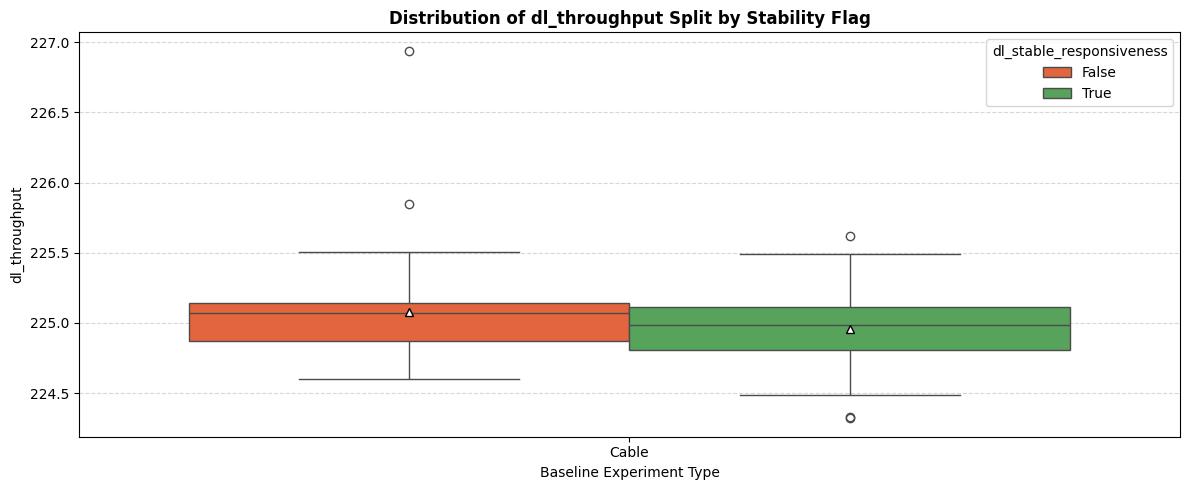


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_CONNECTIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       16.00      16.00      0.00      
True       Cable            98       15.40      16.00      1.37      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


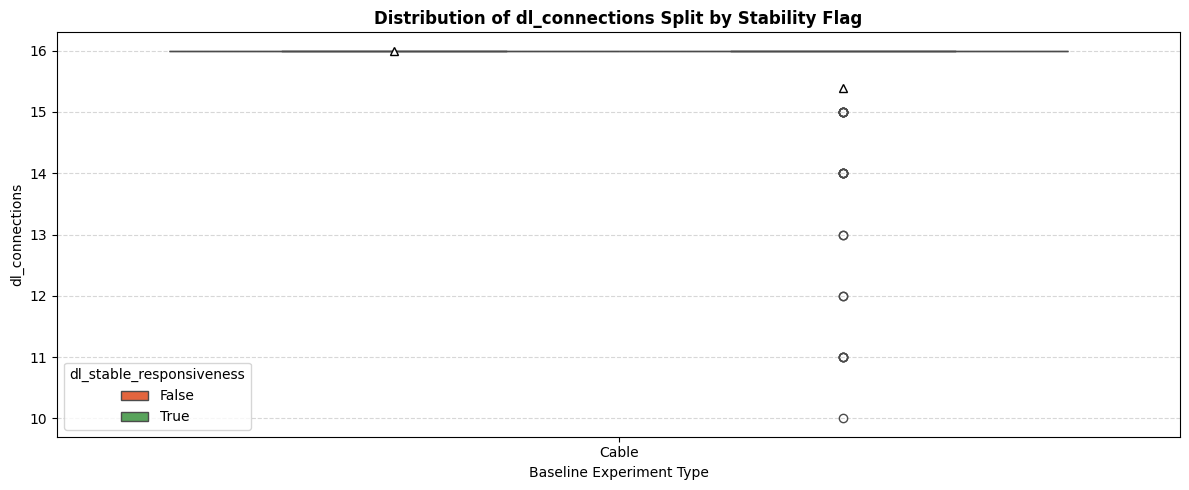


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_RETRANSMISSIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       0.01       0.00       0.10      
True       Cable            98       0.02       0.00       0.14      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


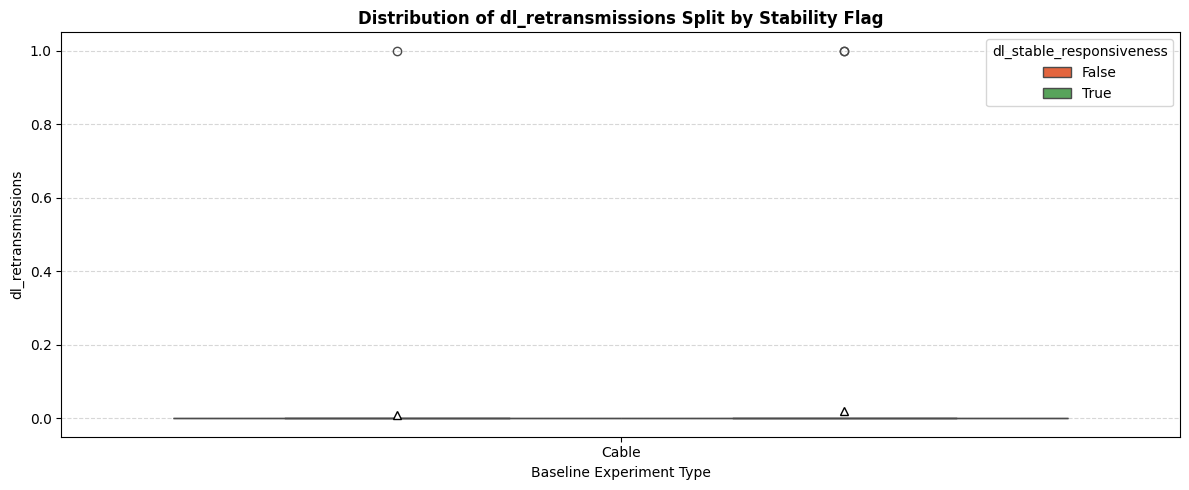


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_REORDER (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       48.00      48.00      0.00      
True       Cable            98       46.84      48.00      3.15      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


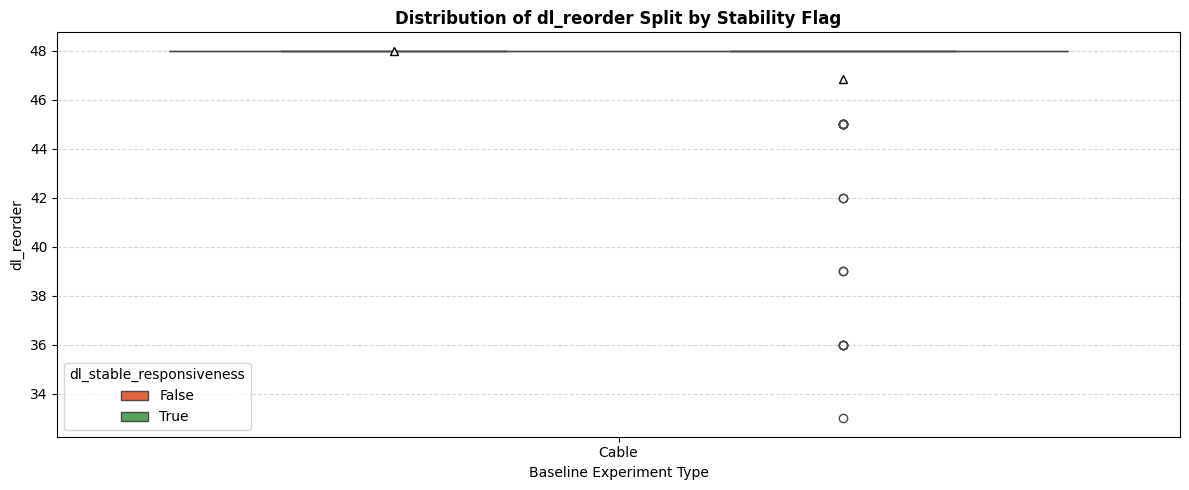


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_AVG_RTT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       22889.40   22867.44   197.46    
True       Cable            98       22850.41   22843.22   248.92    
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


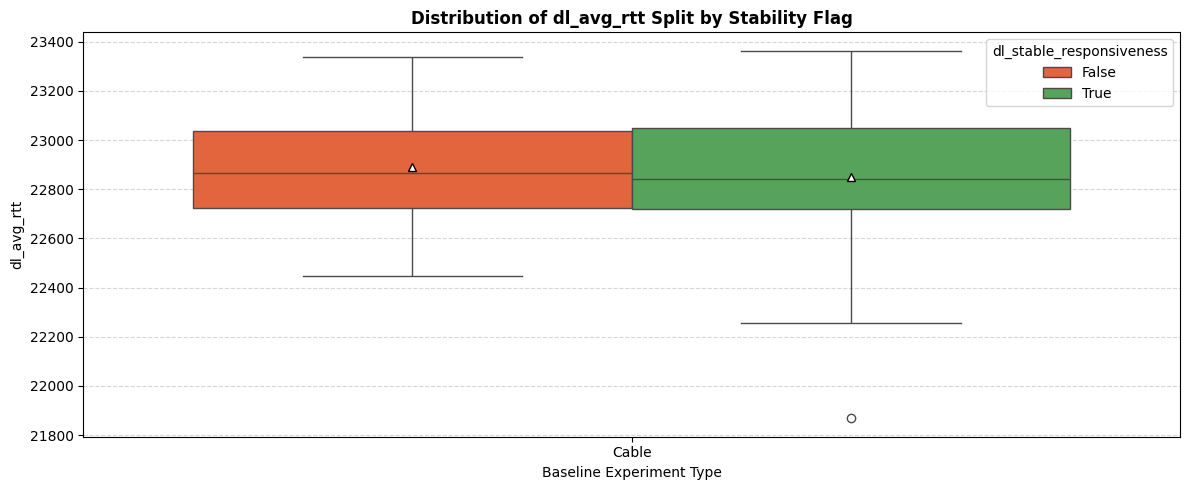


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       375.76     377.00     15.12     
True       Cable            98       395.84     388.00     37.16     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


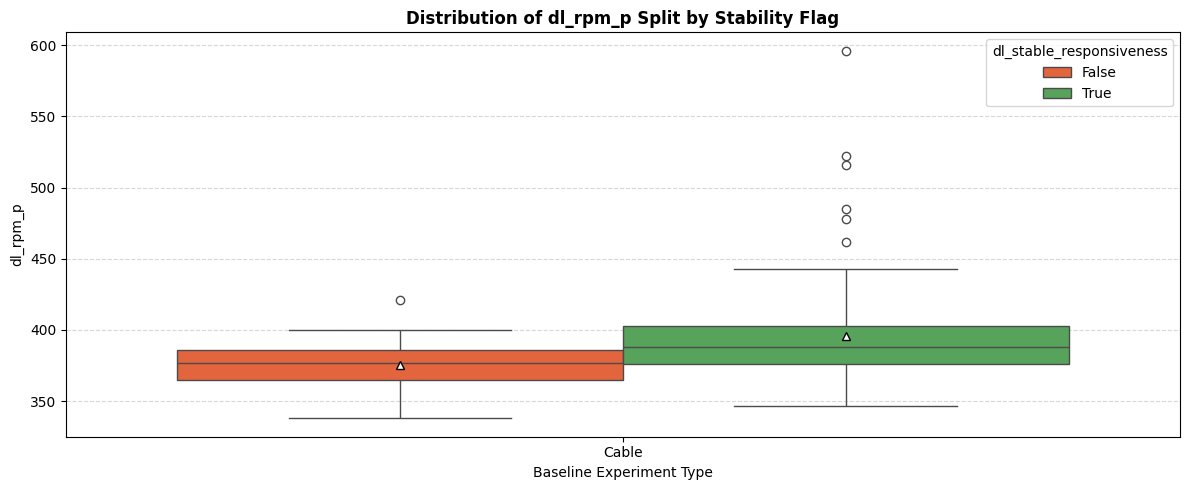


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       706.03     702.50     32.26     
True       Cable            98       749.53     728.00     72.39     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


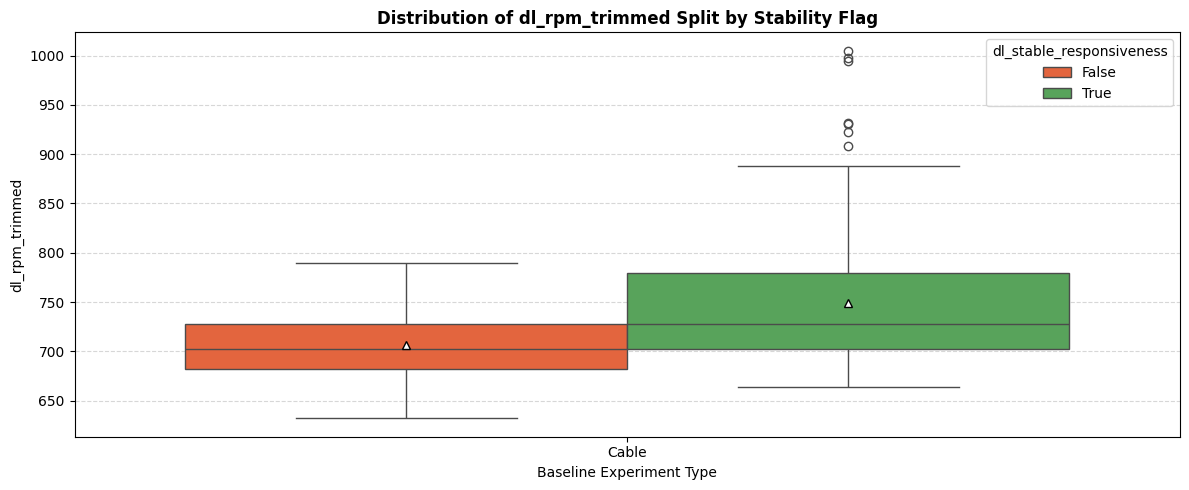


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_THROUGHPUT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       44.32      44.48      1.05      
True       Cable            98       44.41      44.47      0.94      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


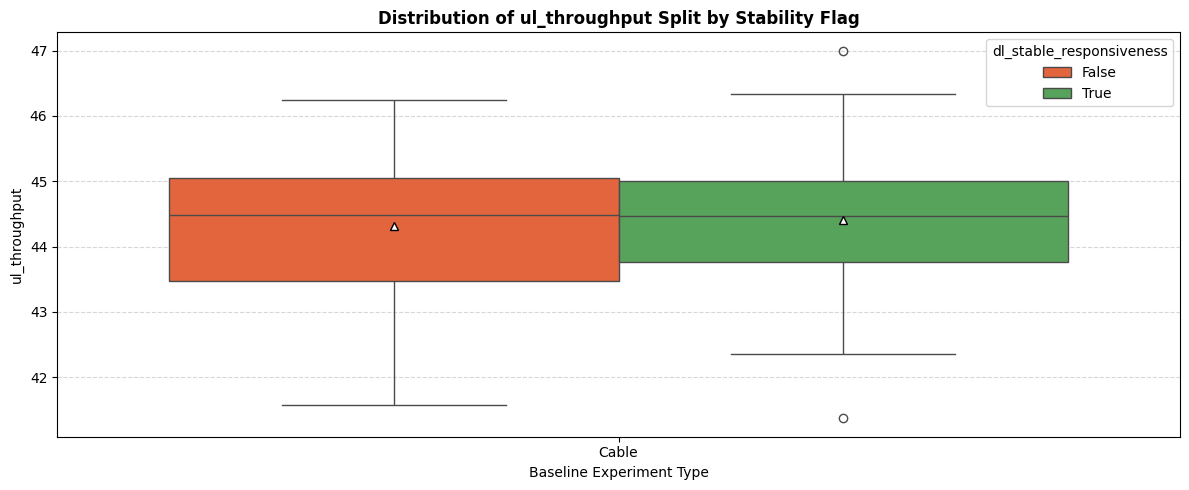


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_CONNECTIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       16.00      16.00      0.00      
True       Cable            98       16.00      16.00      0.00      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


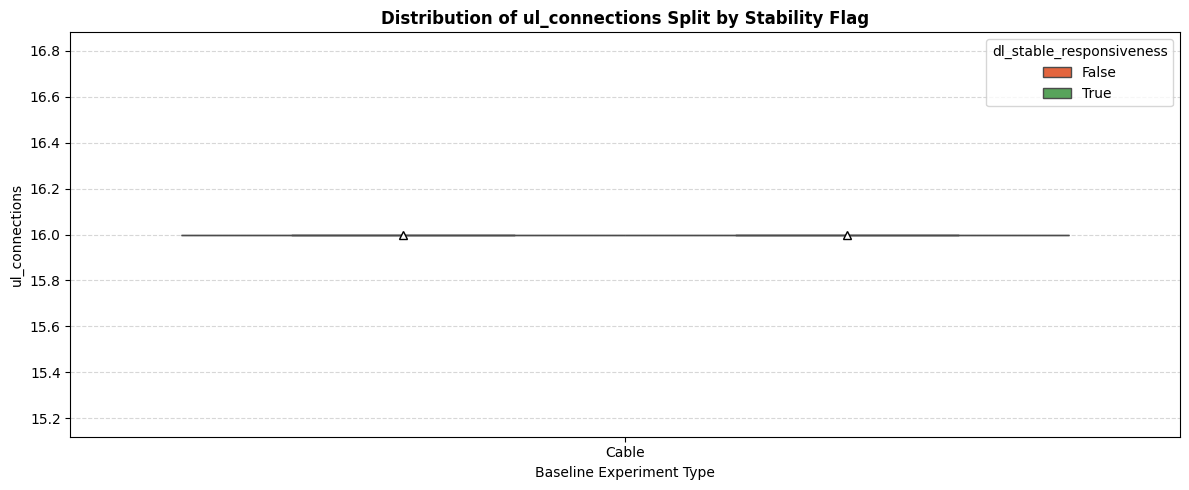


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_RETRANSMISSIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       0.01       0.00       0.10      
True       Cable            98       0.02       0.00       0.14      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


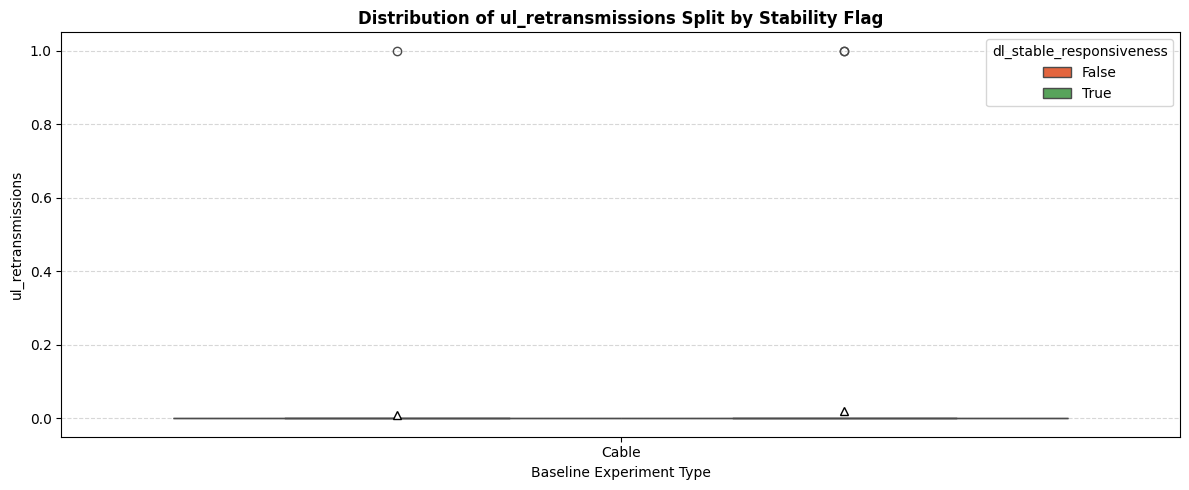


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_REORDER (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       48.32      48.00      1.25      
True       Cable            98       48.22      48.00      1.13      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


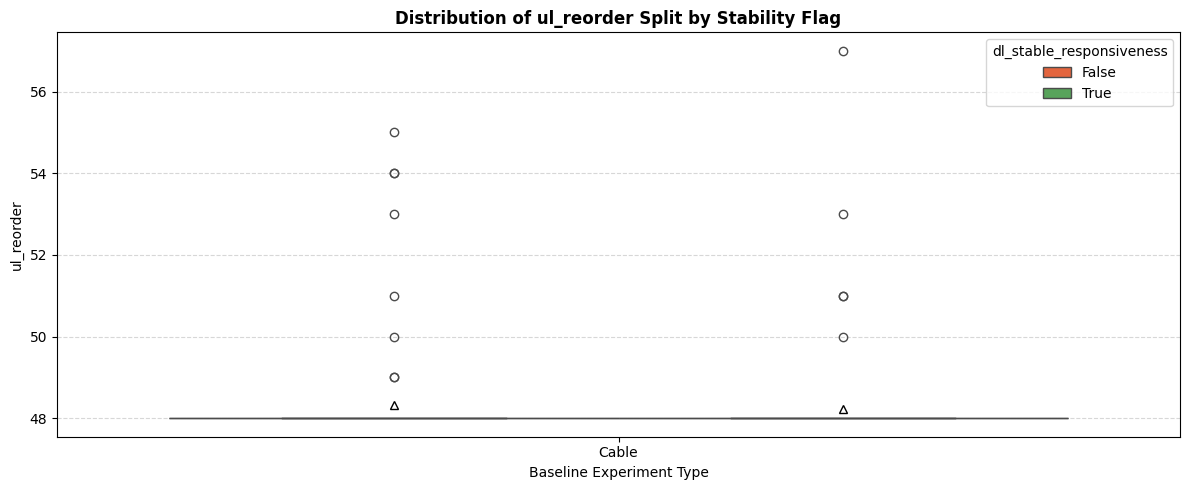


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_AVG_RTT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       31416.97   31403.28   406.27    
True       Cable            98       31433.86   31473.03   367.14    
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


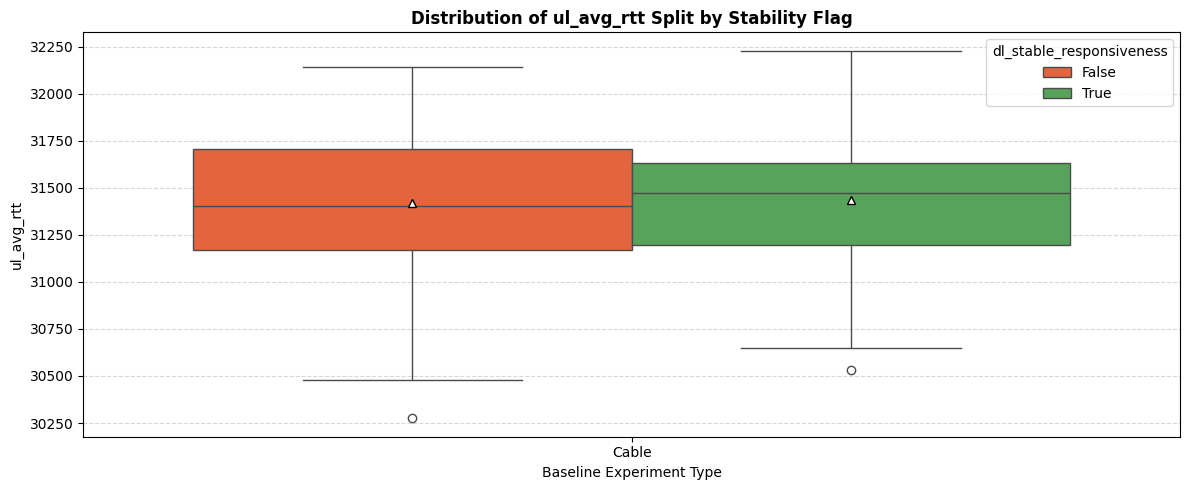


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       84.26      80.00      21.23     
True       Cable            98       78.21      73.50      22.24     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


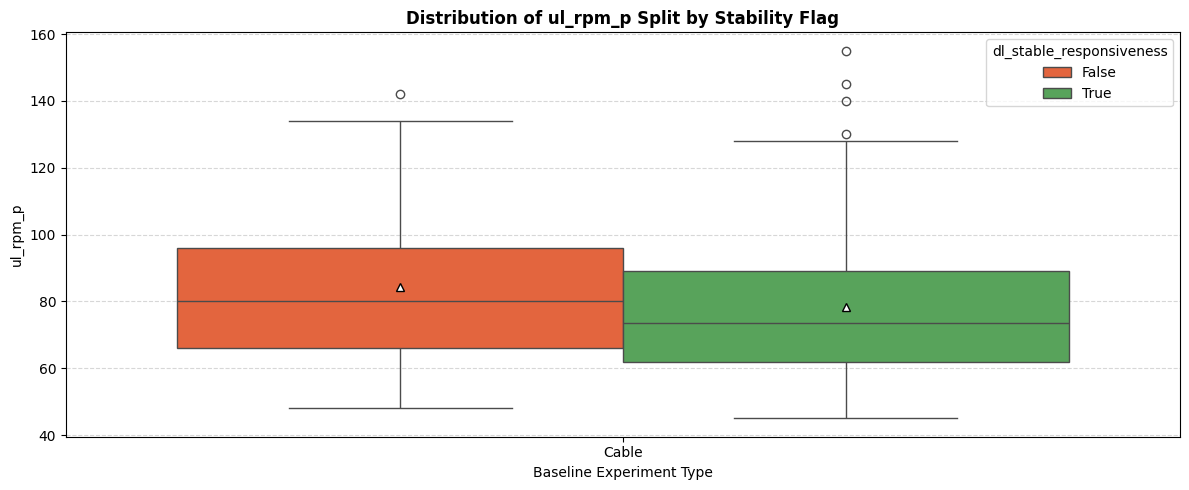


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       417.54     416.00     20.96     
True       Cable            98       412.76     413.50     22.02     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


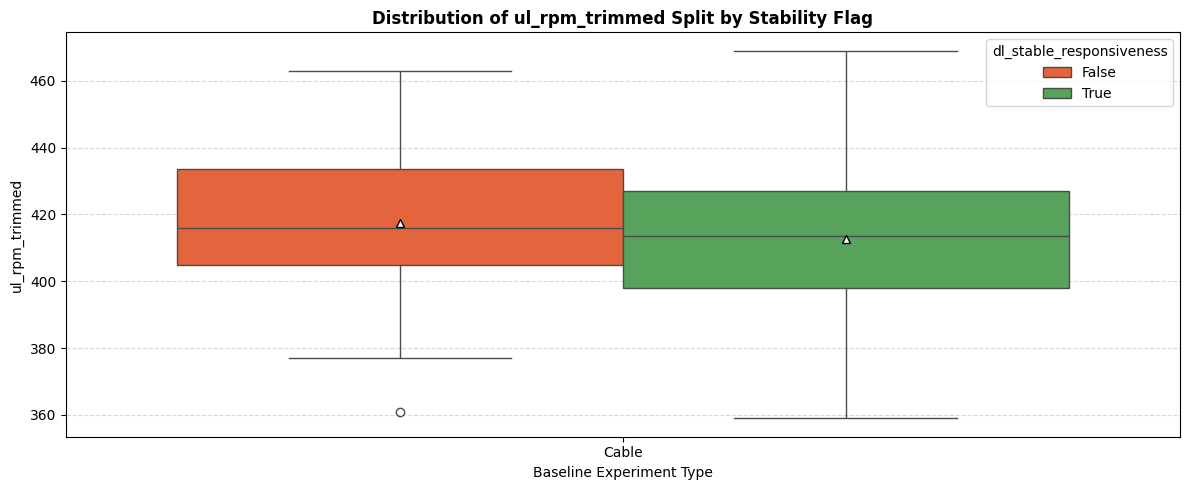


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: FINAL_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       132.98     111.00     64.60     
True       Cable            98       88.46      79.50      39.35     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


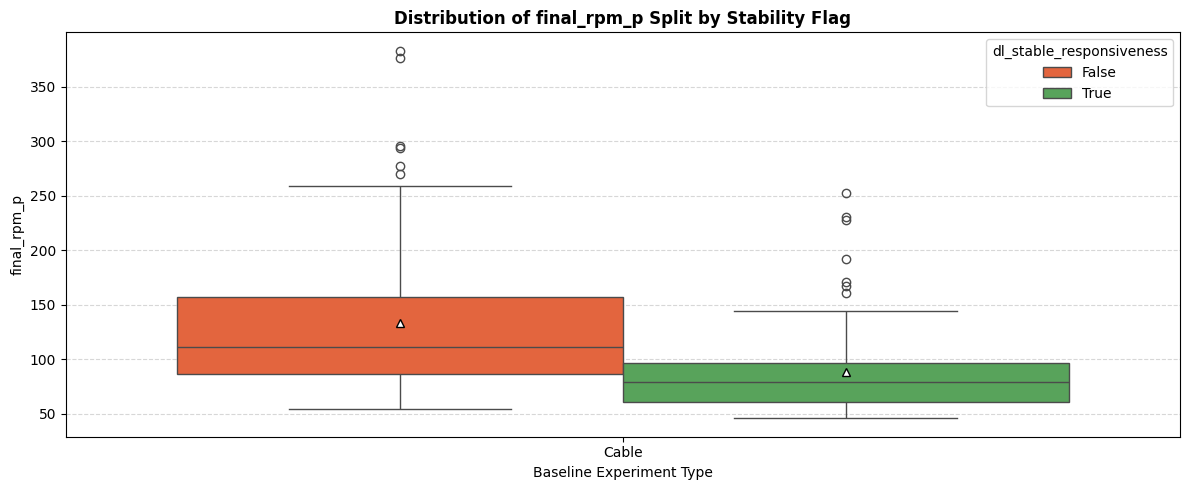


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: FINAL_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       766.52     777.00     50.24     
True       Cable            98       671.58     659.00     58.83     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


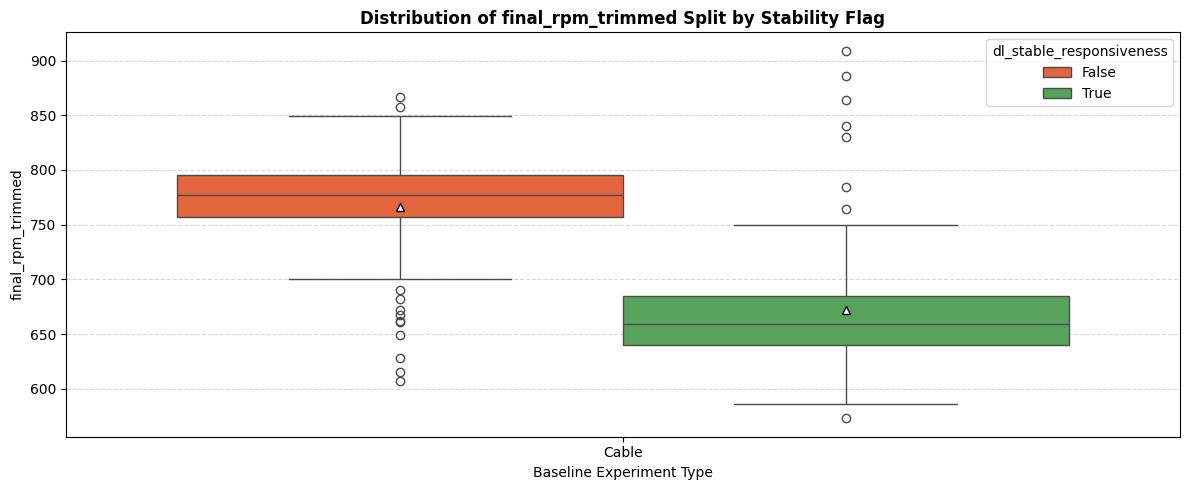


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UB_BASE_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       2815.24    2832.00    34.11     
True       Cable            98       2821.16    2839.00    33.06     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


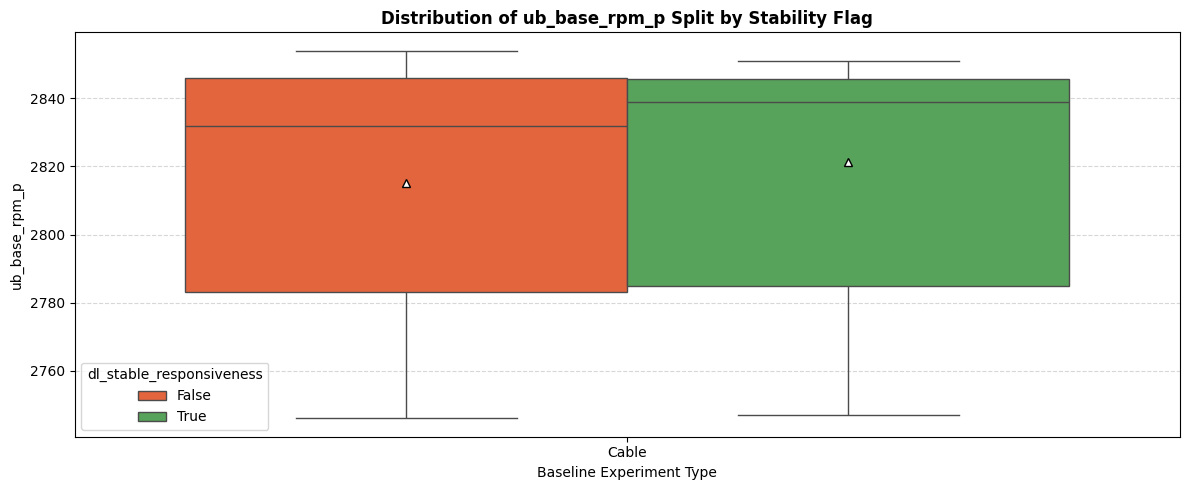


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UB_BASE_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       2866.26    2880.00    20.16     
True       Cable            98       2871.61    2881.00    18.27     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


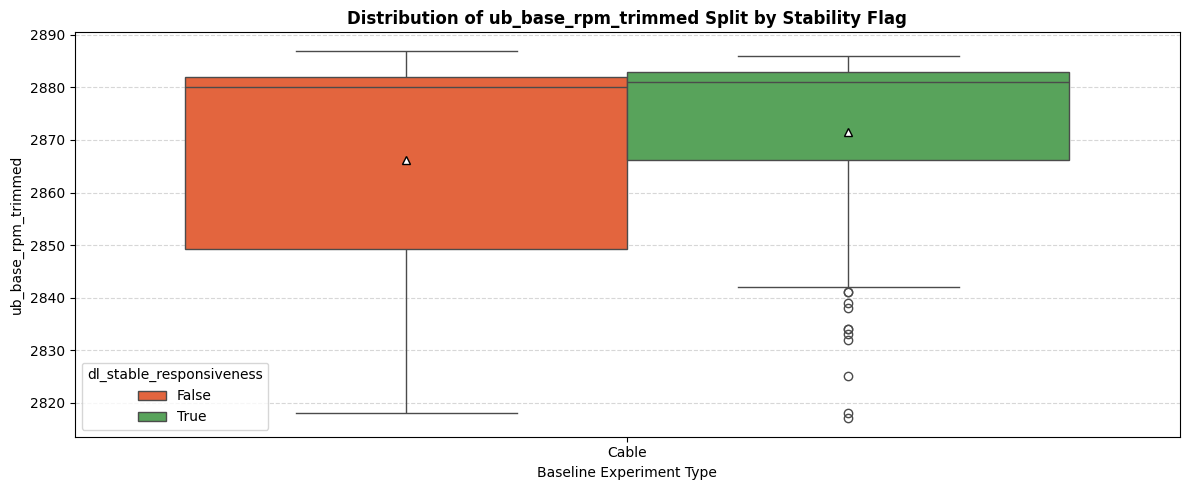


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: BASE_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       2812.49    2829.50    33.48     
True       Cable            98       2819.74    2835.00    32.20     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


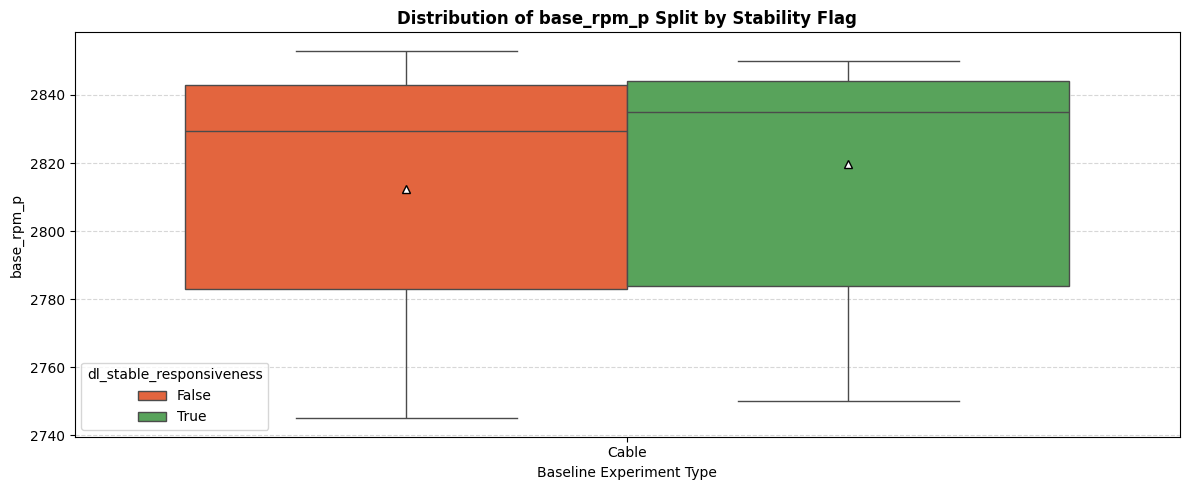


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: BASE_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       2867.83    2880.00    19.02     
True       Cable            98       2872.74    2881.00    17.06     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


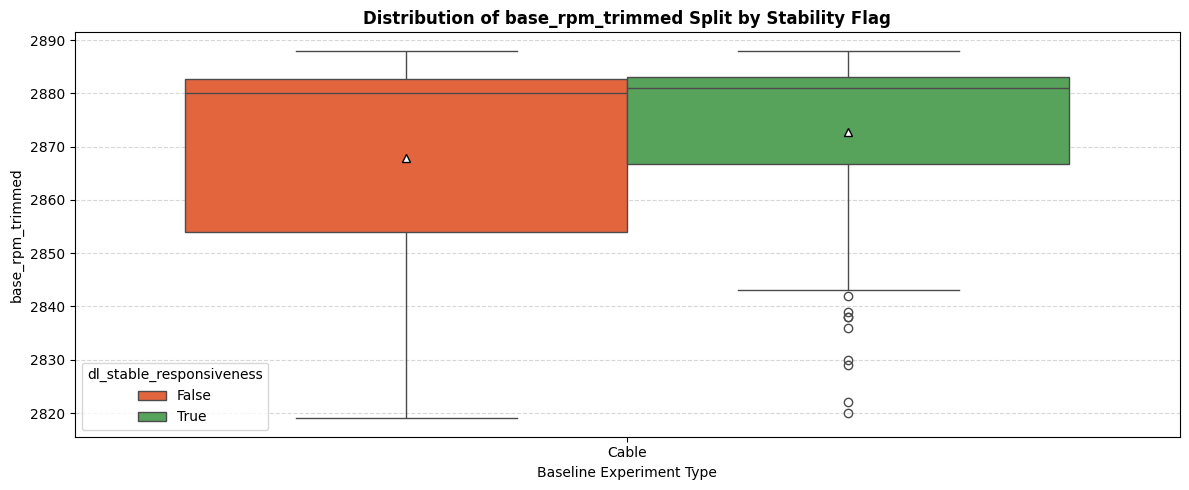


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: WC_EFFECT_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       4.78       4.00       2.36      
True       Cable            98       3.12       3.00       1.42      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


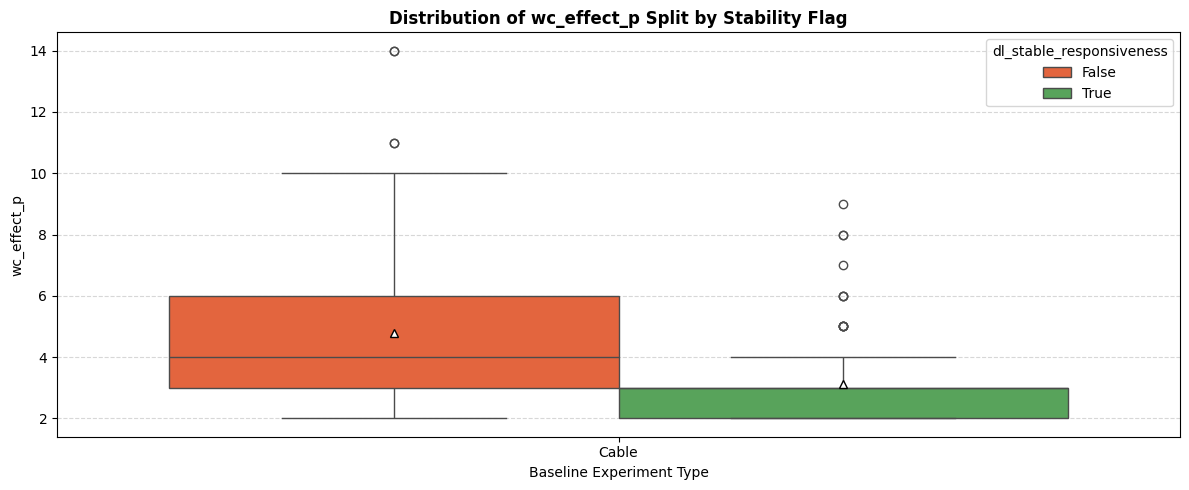


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: WC_EFFECT_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      Cable            98       26.70      27.00      1.73      
True       Cable            98       23.43      23.00      2.06      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


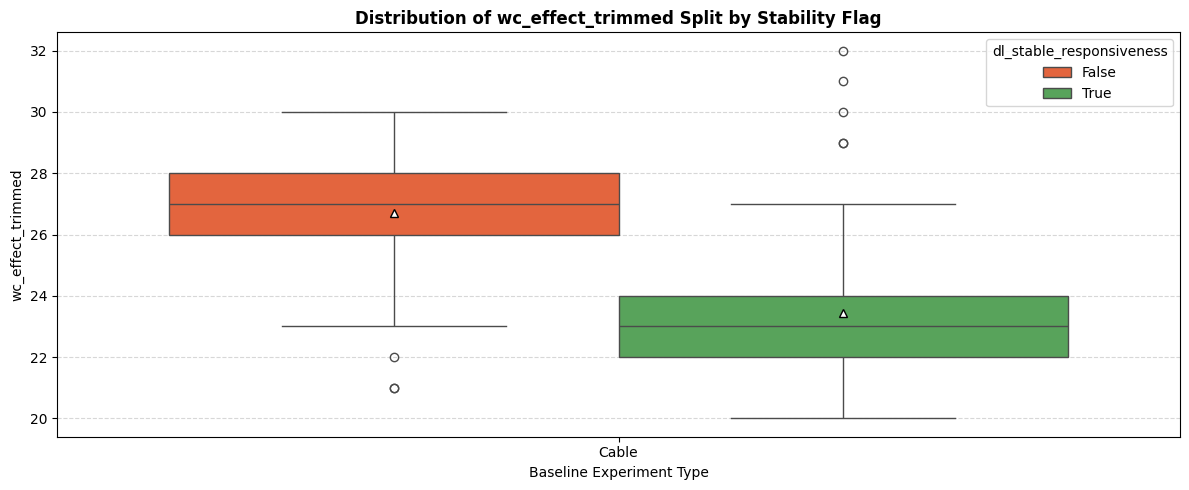


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx



In [24]:
# --- 3. MAIN BLOCK UNIFIED LOOP ---
for col in outputs_for_plots:
    # Skip if the metric is completely missing from the dataframe
    if col not in responsiveness_df.columns:
        continue
    if col in bool_cols:
        continue
        
    # Force numeric parsing to clear out any leftover object data types
    responsiveness_df[col] = pd.to_numeric(responsiveness_df[col], errors='coerce')
    
    # --- A: PRINT STATISTICAL SUMMARY TABLE ---
    print("=" * 85)
    print(f" REPORT & VISUALIZATION FOR METRIC: {col.upper()} (BY STABILITY)")
    print("=" * 85)
    print(f"{'Stability':<10} {'Experiment Type':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10}")
    print("-" * 85)
    
    # Group by both the experiment parameters AND the boolean responsiveness status
    stats = responsiveness_df.groupby(['dl_stable_responsiveness', 'exp_parameters'])[col].agg([
        'count', 'mean', 'median', 'std'
    ]).reset_index()
    
    for _, row in stats.iterrows():
        # Convert boolean to a clean string label for printing
        status_label = "True" if row['dl_stable_responsiveness'] else "False"
        print(f"{status_label:<10} "
              f"{str(row['exp_parameters']):<16} "
              f"{int(row['count']):<8} "
              f"{row['mean']:<10.2f} "
              f"{row['median']:<10.2f} "
              f"{row['std']:<10.2f}")
    print("-" * 85)
    print("\nVisual Side-by-Side Distribution (True vs False):")

    # --- B: RENDER THE SPLIT BOX PLOT ---
    plt.figure(figsize=(12, 5))
    
    # Setting hue='dl_stable_responsiveness' splits the boxes side-by-side
    sns.boxplot(
        data=responsiveness_df, 
        x='exp_parameters', 
        y=col, 
        hue='dl_stable_responsiveness',
        palette={True: '#4CAF50', False: '#FF5722'}, # Using your matching green/orange colors
        showmeans=True,
        meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6}
    )
    
    plt.title(f'Distribution of {col} Split by Stability Flag', fontsize=12, fontweight='bold')
    plt.xlabel('Baseline Experiment Type', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='dl_stable_responsiveness')
    
    plt.tight_layout()
    plt.show()  
    
    print("\n" + "x" * 85 + "\n")

## Stability Throughput

In [25]:
# 1. Drop random True rows to make it even
boolean_counts = throughput_df['ul_stable_throughput'].value_counts()

diff = boolean_counts[True] - boolean_counts[False]

true_indices = throughput_df[throughput_df['ul_stable_throughput'] == True].index

indices_to_drop = throughput_df.loc[true_indices].sample(n=diff, random_state=42).index

throughput_df = throughput_df.drop(index=indices_to_drop)

boolean_counts = throughput_df['ul_stable_throughput'].value_counts()

# 2. create separate dfs for the stable and unstable rows

unstable_throughput_df = throughput_df[throughput_df['ul_stable_throughput'] == False]
stable_throughput_df = throughput_df[throughput_df['ul_stable_throughput'] == True]

In [26]:
print(len(unstable_throughput_df))
print(len(stable_throughput_df))

80
80


Stability

In [27]:
bool_cols = stable_throughput_df.select_dtypes(include=['bool']).columns.tolist()
    
if not bool_cols:
    print(f"No boolean parameters found'\n")
    
print("\n" + "="*65)
print("UL_STABLE_THROUGHPUT = TRUE")    
print("-" * 65)
print(f"{'Boolean Parameter':<25} {'Total Rows':<12} {'True Count':<12} {'Percentage'}")
print("-" * 65)

# 3. Calculate metrics for each boolean column
for col in bool_cols:
    total_rows = len(stable_throughput_df)
    true_count = stable_throughput_df[col].sum()  # Summing a boolean column counts the True values
    
    # Avoid division by zero just in case the filtered dataframe is empty
    percentage = (true_count / total_rows * 100) if total_rows > 0 else 0.0
    
    print(f"{col:<25} {total_rows:<12} {true_count:<12} {percentage:.2f}%")

print("\n" + "="*65 + "\n")

bool_cols = unstable_throughput_df.select_dtypes(include=['bool']).columns.tolist()
    
if not bool_cols:
    print(f"No boolean parameters found'\n")
    
print("\n" + "="*65)
print("UL_STABLE_THROUGHPUT = FALSE")      
print("-" * 65)
print(f"{'Boolean Parameter':<25} {'Total Rows':<12} {'True Count':<12} {'Percentage'}")
print("-" * 65)

# 3. Calculate metrics for each boolean column
for col in bool_cols:
    total_rows = len(unstable_throughput_df)
    true_count = unstable_throughput_df[col].sum()  # Summing a boolean column counts the True values
    
    # Avoid division by zero just in case the filtered dataframe is empty
    percentage = (true_count / total_rows * 100) if total_rows > 0 else 0.0
    
    print(f"{col:<25} {total_rows:<12} {true_count:<12} {percentage:.2f}%")

print("\n" + "="*65 + "\n")


UL_STABLE_THROUGHPUT = TRUE
-----------------------------------------------------------------
Boolean Parameter         Total Rows   True Count   Percentage
-----------------------------------------------------------------
dl_stable_throughput      80           79           98.75%
dl_stable_responsiveness  80           37           46.25%
ul_stable_throughput      80           80           100.00%
ul_stable_responsiveness  80           0            0.00%



UL_STABLE_THROUGHPUT = FALSE
-----------------------------------------------------------------
Boolean Parameter         Total Rows   True Count   Percentage
-----------------------------------------------------------------
dl_stable_throughput      80           79           98.75%
dl_stable_responsiveness  80           37           46.25%
ul_stable_throughput      80           0            0.00%
ul_stable_responsiveness  80           0            0.00%




Numeric Values

 REPORT & VISUALIZATION FOR METRIC: DL_THROUGHPUT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       88.98      88.99      0.23      
True       VDSL mad         74       88.95      88.99      0.28      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


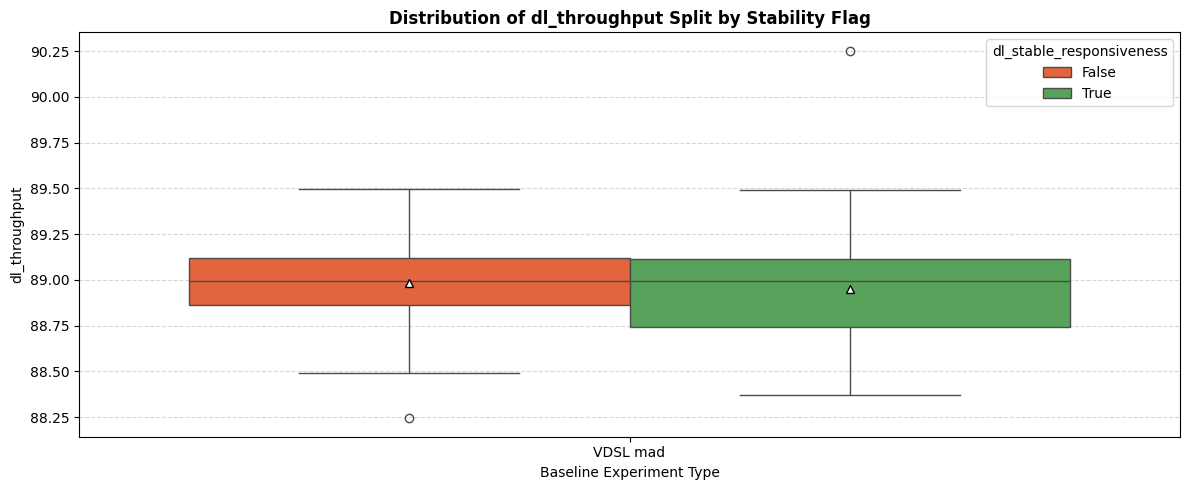


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_CONNECTIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       16.00      16.00      0.00      
True       VDSL mad         74       15.73      16.00      0.75      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


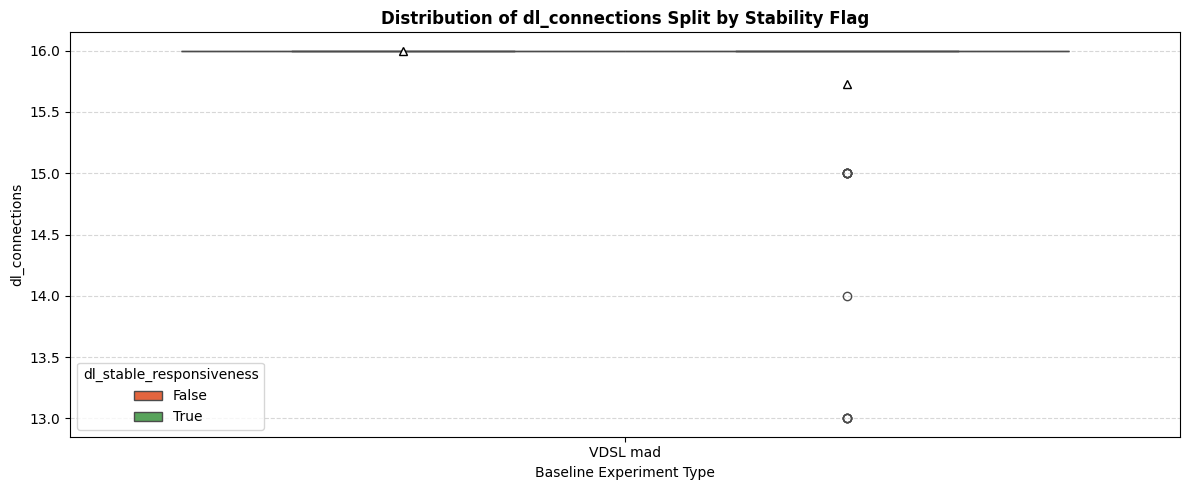


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_RETRANSMISSIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       0.00       0.00       0.00      
True       VDSL mad         74       0.00       0.00       0.00      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


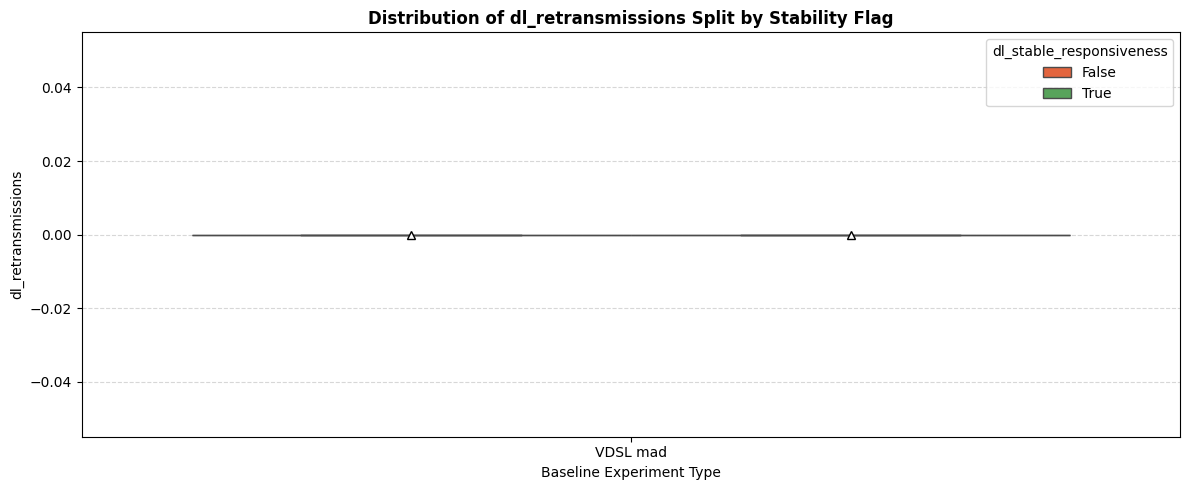


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_REORDER (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       48.00      48.00      0.00      
True       VDSL mad         74       47.47      48.00      1.75      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


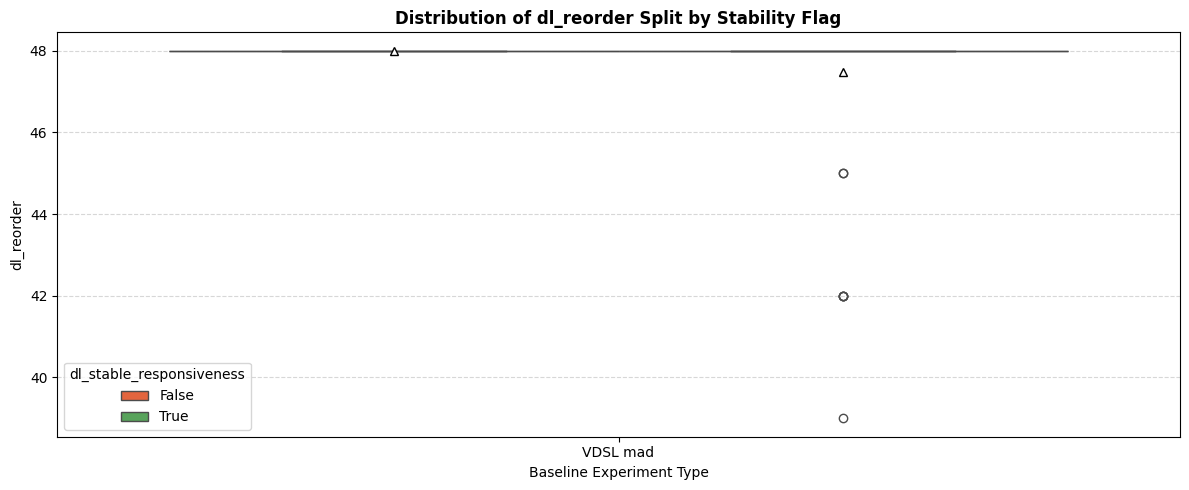


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_AVG_RTT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       15404.48   15375.94   201.59    
True       VDSL mad         74       15266.80   15310.62   236.89    
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


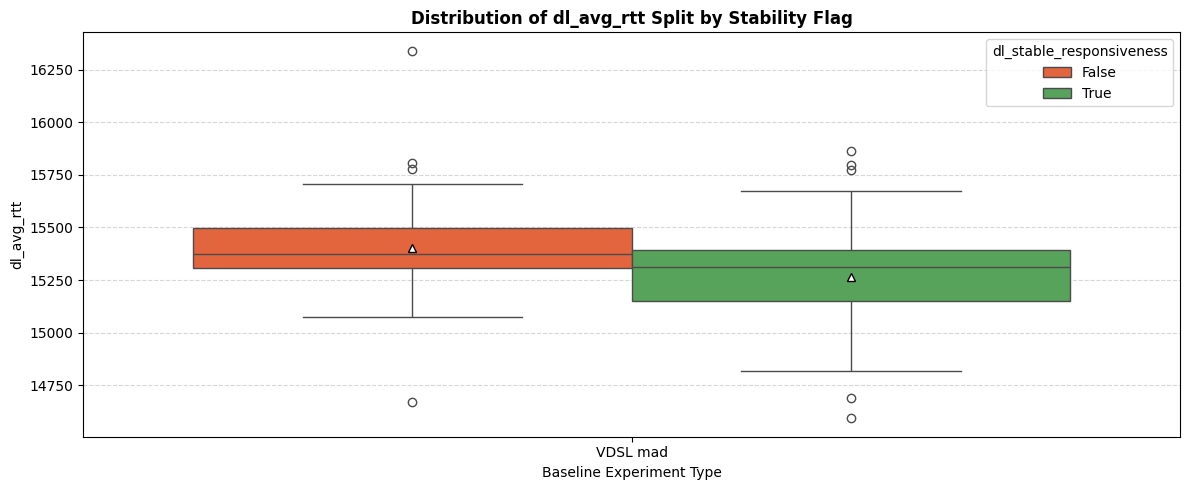


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       341.47     342.00     12.16     
True       VDSL mad         74       365.69     358.00     26.98     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


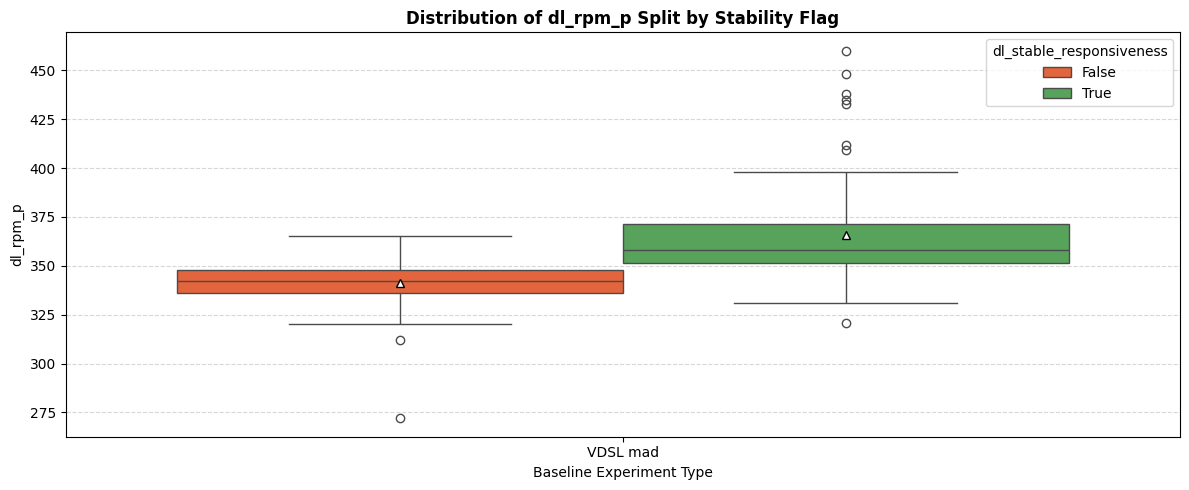


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: DL_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       705.59     705.00     21.13     
True       VDSL mad         74       752.72     742.50     51.05     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


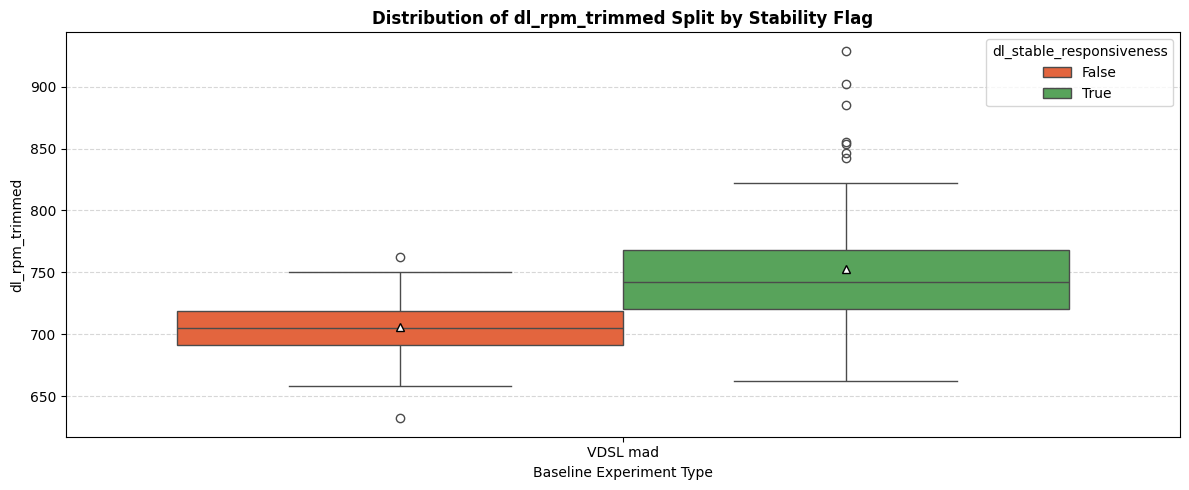


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_THROUGHPUT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       35.47      35.48      0.64      
True       VDSL mad         74       35.31      35.36      0.73      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


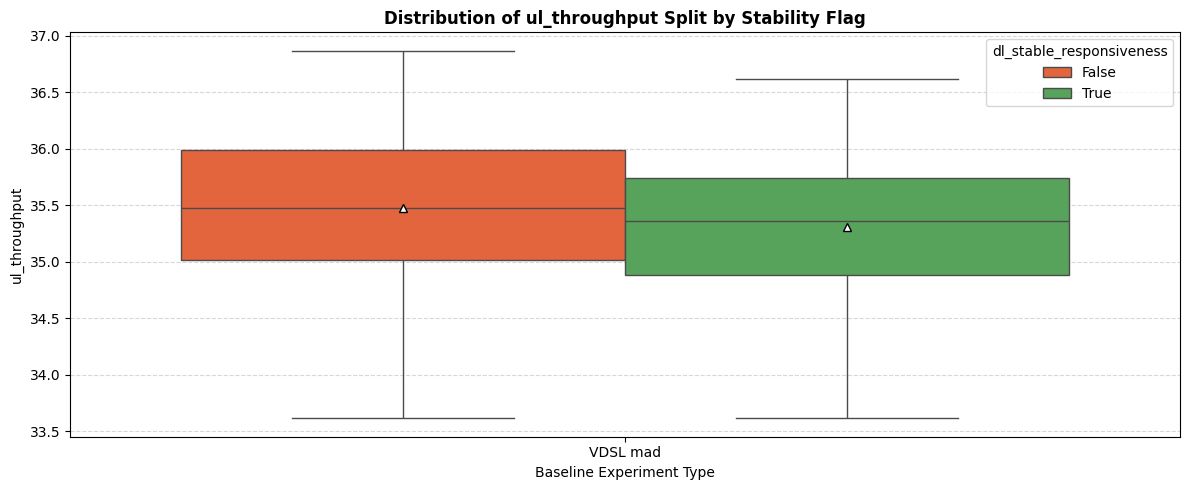


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_CONNECTIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       16.00      16.00      0.00      
True       VDSL mad         74       16.00      16.00      0.00      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


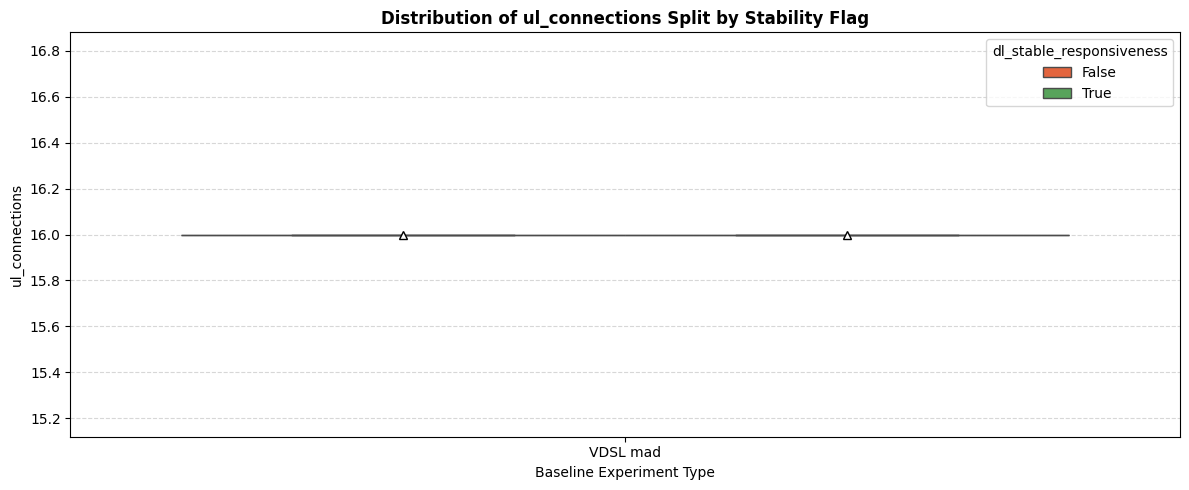


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_RETRANSMISSIONS (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       644.16     554.50     362.99    
True       VDSL mad         74       628.14     534.50     369.02    
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


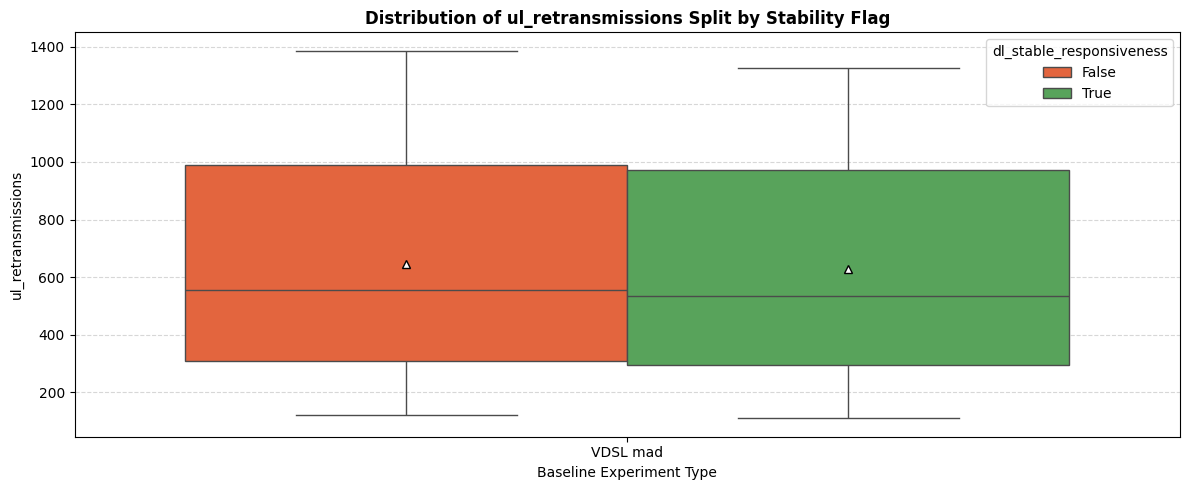


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_REORDER (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       48.07      48.00      0.40      
True       VDSL mad         74       48.03      48.00      0.16      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


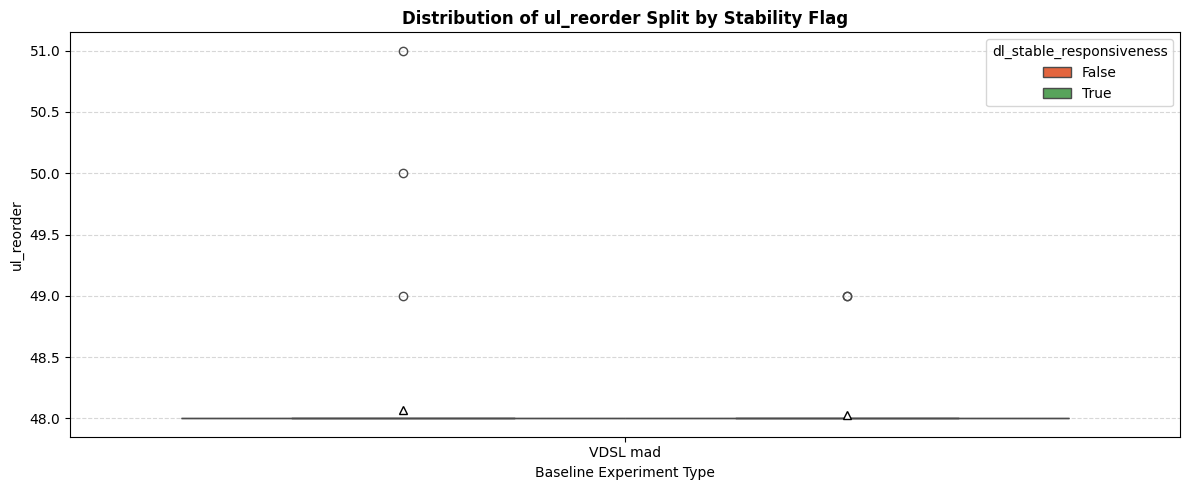


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_AVG_RTT (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       23415.21   23402.69   580.03    
True       VDSL mad         74       23457.94   23493.81   453.64    
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


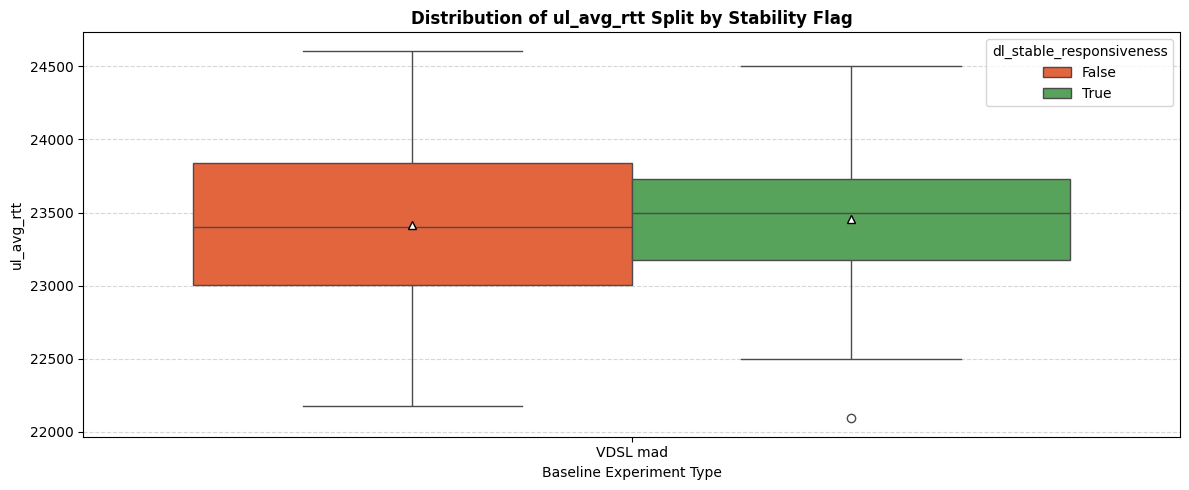


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       71.14      58.00      33.91     
True       VDSL mad         74       68.46      56.00      31.05     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


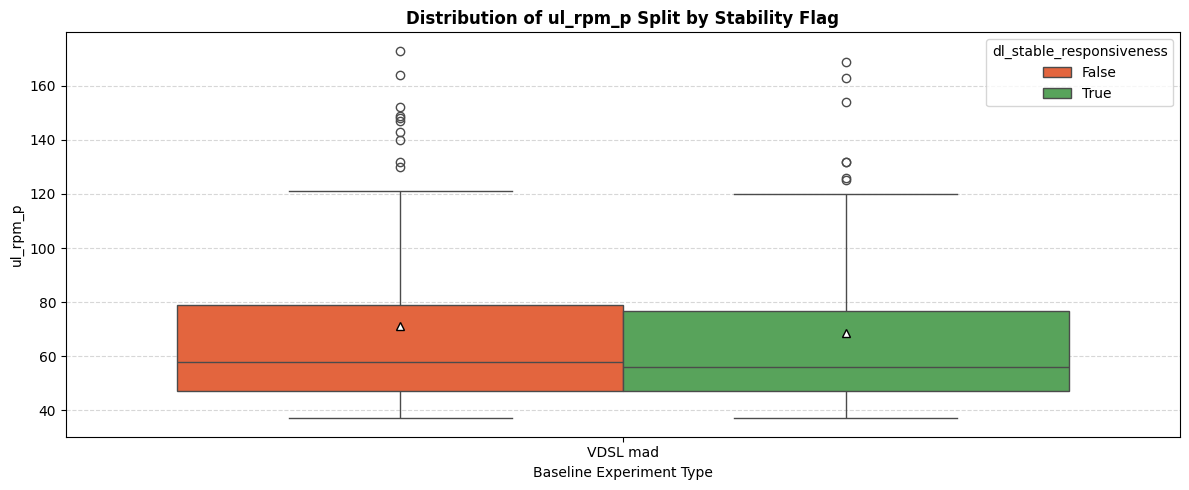


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UL_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       447.33     452.00     51.63     
True       VDSL mad         74       445.70     458.50     45.30     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


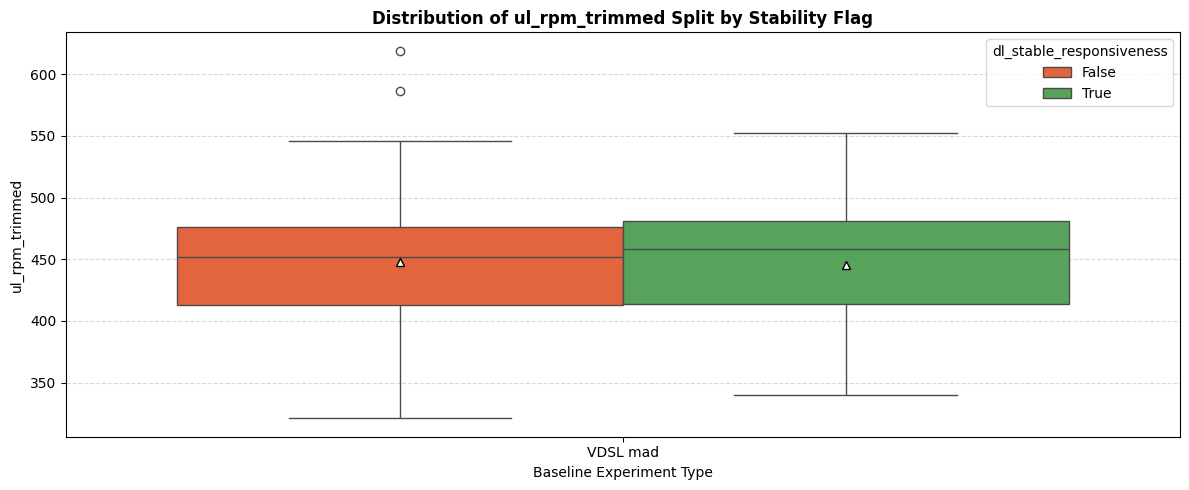


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: FINAL_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       114.94     80.00      74.10     
True       VDSL mad         74       91.72      70.50      57.87     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


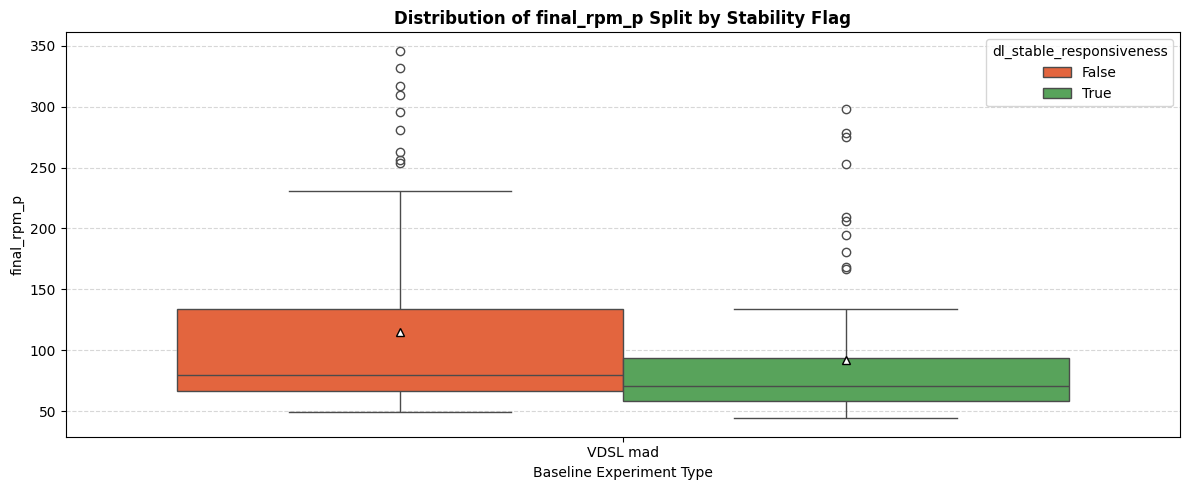


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: FINAL_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       740.81     739.50     65.37     
True       VDSL mad         74       696.08     682.00     49.33     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


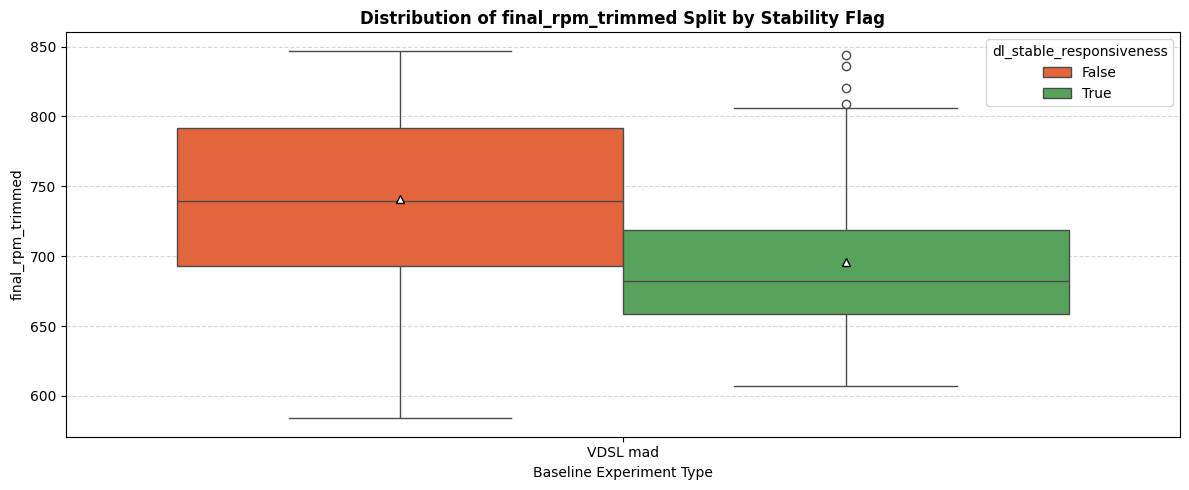


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UB_BASE_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       5399.98    5439.00    89.15     
True       VDSL mad         74       5413.36    5440.00    77.12     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


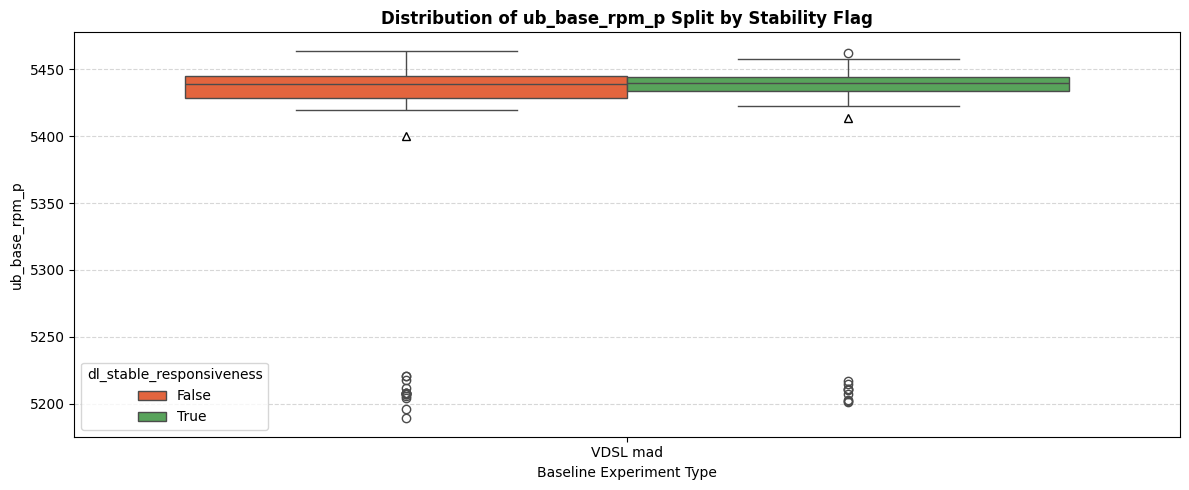


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: UB_BASE_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       5536.15    5558.00    53.38     
True       VDSL mad         74       5547.93    5558.00    35.63     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


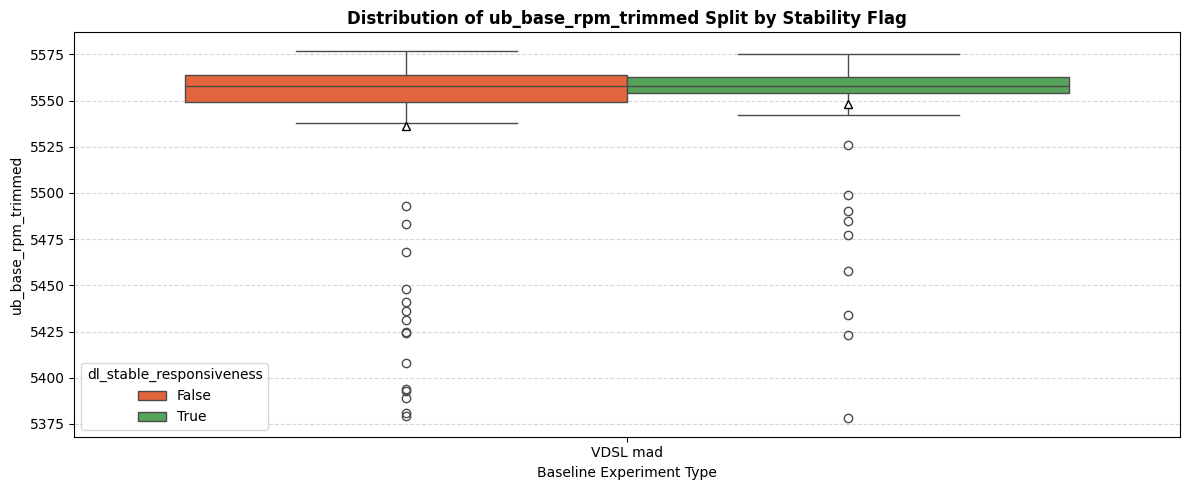


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: BASE_RPM_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       5402.42    5442.00    89.91     
True       VDSL mad         74       5415.43    5442.00    77.58     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


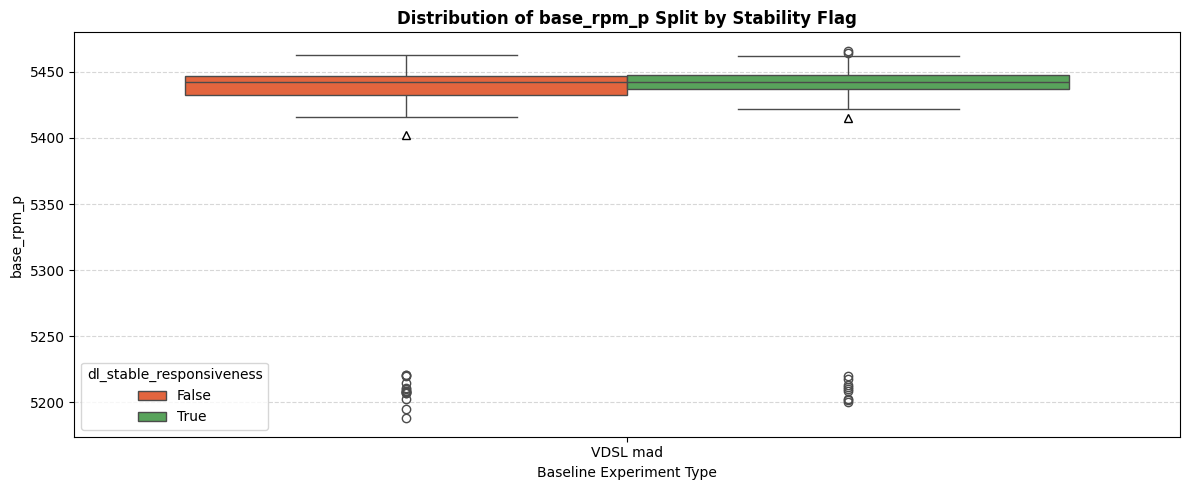


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: BASE_RPM_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       5538.58    5558.00    50.56     
True       VDSL mad         74       5550.43    5559.00    32.21     
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


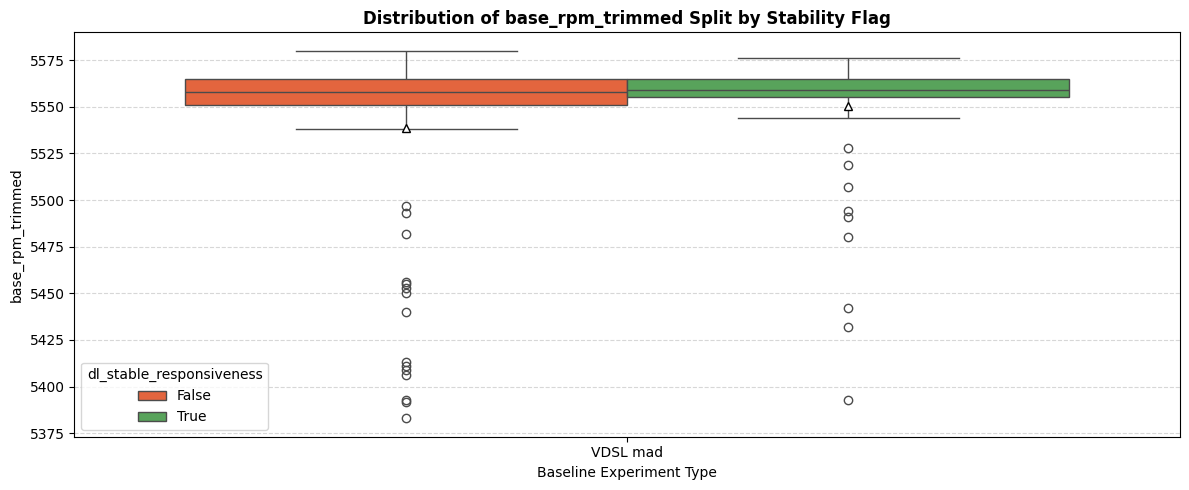


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: WC_EFFECT_P (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       2.02       1.00       1.45      
True       VDSL mad         74       1.69       1.00       1.10      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


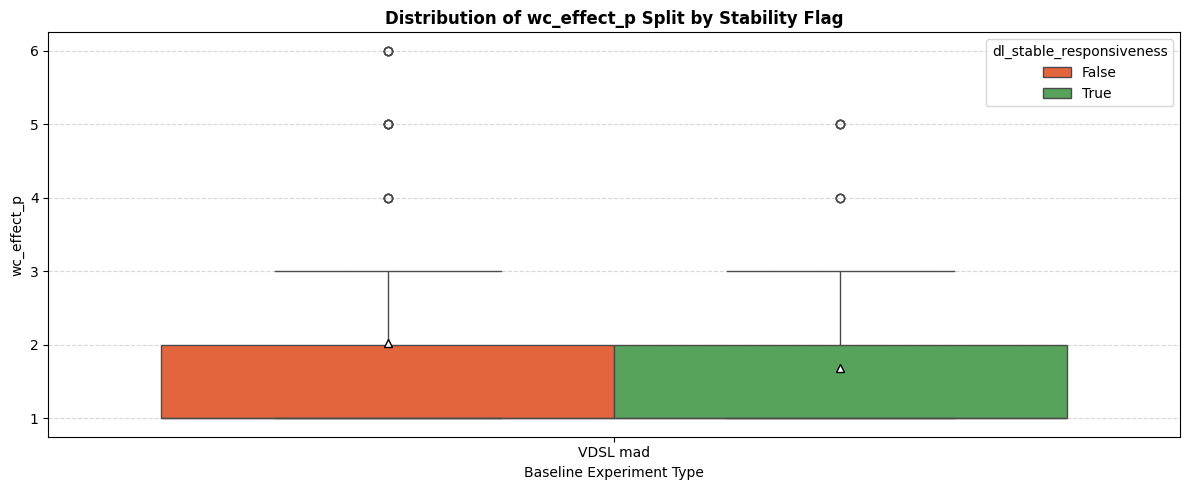


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

 REPORT & VISUALIZATION FOR METRIC: WC_EFFECT_TRIMMED (BY STABILITY)
Stability  Experiment Type  Count    Mean       Median     Std Dev   
-------------------------------------------------------------------------------------
False      VDSL mad         86       13.40      13.00      1.22      
True       VDSL mad         74       12.50      12.00      0.93      
-------------------------------------------------------------------------------------

Visual Side-by-Side Distribution (True vs False):


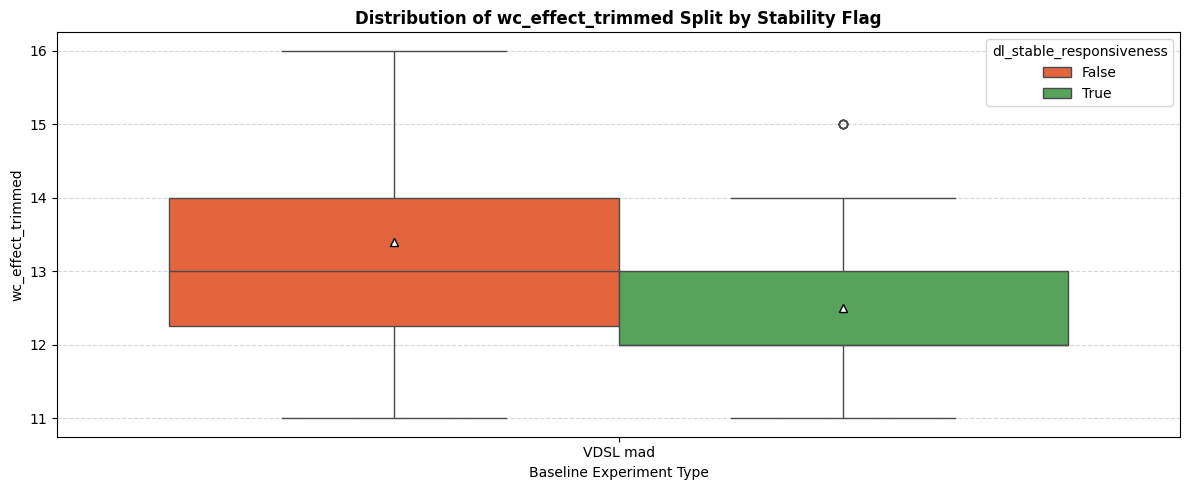


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx



In [28]:
# --- 3. MAIN BLOCK UNIFIED LOOP ---
for col in outputs_for_plots:
    # Skip if the metric is completely missing from the dataframe
    if col not in throughput_df.columns:
        continue
    if col in bool_cols:
        continue
        
    # Force numeric parsing to clear out any leftover object data types
    throughput_df[col] = pd.to_numeric(throughput_df[col], errors='coerce')
    
    # --- A: PRINT STATISTICAL SUMMARY TABLE ---
    print("=" * 85)
    print(f" REPORT & VISUALIZATION FOR METRIC: {col.upper()} (BY STABILITY)")
    print("=" * 85)
    print(f"{'Stability':<10} {'Experiment Type':<16} {'Count':<8} {'Mean':<10} {'Median':<10} {'Std Dev':<10}")
    print("-" * 85)
    
    # Group by both the experiment parameters AND the boolean responsiveness status
    stats = throughput_df.groupby(['dl_stable_responsiveness', 'exp_parameters'])[col].agg([
        'count', 'mean', 'median', 'std'
    ]).reset_index()
    
    for _, row in stats.iterrows():
        # Convert boolean to a clean string label for printing
        status_label = "True" if row['dl_stable_responsiveness'] else "False"
        print(f"{status_label:<10} "
              f"{str(row['exp_parameters']):<16} "
              f"{int(row['count']):<8} "
              f"{row['mean']:<10.2f} "
              f"{row['median']:<10.2f} "
              f"{row['std']:<10.2f}")
    print("-" * 85)
    print("\nVisual Side-by-Side Distribution (True vs False):")

    # --- B: RENDER THE SPLIT BOX PLOT ---
    plt.figure(figsize=(12, 5))
    
    # Setting hue='dl_stable_responsiveness' splits the boxes side-by-side
    sns.boxplot(
        data=throughput_df, 
        x='exp_parameters', 
        y=col, 
        hue='dl_stable_responsiveness',
        palette={True: '#4CAF50', False: '#FF5722'}, # Using your matching green/orange colors
        showmeans=True,
        meanprops={"marker": "^", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6}
    )
    
    plt.title(f'Distribution of {col} Split by Stability Flag', fontsize=12, fontweight='bold')
    plt.xlabel('Baseline Experiment Type', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='dl_stable_responsiveness')
    
    plt.tight_layout()
    plt.show()  
    
    print("\n" + "x" * 85 + "\n")